In [1]:
# Import packages and modules
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow_decision_forests as tfdf

from sklearn.model_selection import train_test_split

2026-07-04 08:27:08.590947: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-04 08:27:08.635805: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-07-04 08:27:12.922163: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
# Check the version of TensorFlow Decision Forests
print("Found TensorFlow Decision Forests v" + tfdf.__version__)

Found TensorFlow Decision Forests v1.9.1


In [3]:
datasetPath = 'dataset/firstorder/kernel5-radius5/dataset.csv'

In [4]:
# Parameters
datasetPath = "dataset/glcm/kernel5-radius5/100.dataset.csv"


In [5]:
# train/validation/test = 70/10/20
dataset = pd.read_csv(datasetPath)

train_data, temp_data = train_test_split(dataset, test_size=0.3, random_state=42)
validation_data, test_data = train_test_split(temp_data, test_size=2/3, random_state=42)

In [6]:
from sklearn.utils.class_weight import compute_class_weight

# tinh class weight tren tap train
classes = np.array([0, 1])
weights = compute_class_weight(class_weight="balanced", classes=classes, y=train_data["label"])
class_weight = {0: weights[0], 1: weights[1]}

# gan sample_weight cho tung dong
train_data["sample_weight"] = train_data["label"].map(class_weight)
validation_data["sample_weight"] = validation_data["label"].map(class_weight)
test_data["sample_weight"] = test_data["label"].map(class_weight)

# Convert the dataset into a TensorFlow dataset.
train_ds = tfdf.keras.pd_dataframe_to_tf_dataset(
    train_data, label="label", weight="sample_weight"
)         
val_ds = tfdf.keras.pd_dataframe_to_tf_dataset(
    validation_data, label="label", weight="sample_weight"
)
test_ds = tfdf.keras.pd_dataframe_to_tf_dataset(
    test_data, label="label", weight="sample_weight"
)

2026-07-04 08:27:25.041084: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-07-04 08:27:25.042684: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [7]:
import keras

In [8]:
%%time

# Train a Random Forest model.
model = tfdf.keras.RandomForestModel()

# Add evaluation metrics
model.compile(
    metrics=["accuracy"]
)
model.fit(x=train_ds)

# # Train a Gradient Boosted Trees model.
# model = tfdf.keras.GradientBoostedTreesModel(num_trees=1500)
# model.fit(train_ds)

Use /tmp/tmp91fa9b0j as temporary training directory


Reading training dataset...


Training dataset read in 0:00:04.446617. Found 78712 examples.


Training model...


[INFO 26-07-04 08:27:37.3736 UTC kernel.cc:1233] Loading model from path /tmp/tmp91fa9b0j/model/ with prefix 62efb247326e47cc


Model trained in 0:00:08.491612


Compiling model...


[INFO 26-07-04 08:27:38.0583 UTC decision_forest.cc:734] Model loaded with 300 root(s), 596892 node(s), and 24 input feature(s).
[INFO 26-07-04 08:27:38.0583 UTC abstract_model.cc:1362] Engine "RandomForestOptPred" built
[INFO 26-07-04 08:27:38.0583 UTC kernel.cc:1061] Use fast generic engine


Model compiled.


CPU times: user 1min 35s, sys: 982 ms, total: 1min 36s
Wall time: 16.2 s


In [9]:
# Evaluate the model
evaluate = model.evaluate(val_ds, return_dict=True)
print()

for name, value in evaluate.items():
    print(f"{name}: {value:.4f}")

 1/12 [=>............................] - ETA: 32s - loss: 0.0000e+00 - accuracy: 0.9710

 4/12 [=========>....................] - ETA: 0s - loss: 0.0000e+00 - accuracy: 0.9712 

 7/12 [================>.............] - ETA: 0s - loss: 0.0000e+00 - accuracy: 0.9717

 9/12 [=====================>........] - ETA: 0s - loss: 0.0000e+00 - accuracy: 0.9716

12/12 [==============================] - ETA: 0s - loss: 0.0000e+00 - accuracy: 0.9711

12/12 [==============================] - 3s 23ms/step - loss: 0.0000e+00 - accuracy: 0.9711



loss: 0.0000
accuracy: 0.9711


In [10]:
# Model Summary
model.summary()

Model: "random_forest_model"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


Total params: 1 (1.00 Byte)


Trainable params: 0 (0.00 Byte)


Non-trainable params: 1 (1.00 Byte)


_________________________________________________________________


Type: "RANDOM_FOREST"
Task: CLASSIFICATION
Label: "__LABEL"

Input Features (24):
	Autocorrelation
	ClusterProminence
	ClusterShade
	ClusterTendency
	Contrast
	Correlation
	DifferenceAverage
	DifferenceEntropy
	DifferenceVariance
	Id
	Idm
	Idmn
	Idn
	Imc1
	Imc2
	InverseVariance
	JointAverage
	JointEnergy
	JointEntropy
	MCC
	MaximumProbability
	SumAverage
	SumEntropy
	SumSquares

Trained with weights

Variable Importance: INV_MEAN_MIN_DEPTH:
    1.    "Autocorrelation"  0.158580 ################
    2.         "SumAverage"  0.148222 #############
    3.       "JointAverage"  0.142913 ############
    4.        "Correlation"  0.132489 ##########
    5.               "Imc1"  0.126366 #########
    6.                "MCC"  0.108334 #####
    7.    "InverseVariance"  0.103905 ####
    8. "DifferenceVariance"  0.101583 ####
    9.                "Idn"  0.096353 ###
   10.           "Contrast"  0.094945 ##
   11.  "DifferenceEntropy"  0.094450 ##
   12.               "Idmn"  0.093895 ##
   13

In [11]:
# Model features
model.make_inspector().features()

["Autocorrelation" (1; #0),
 "ClusterProminence" (1; #1),
 "ClusterShade" (1; #2),
 "ClusterTendency" (1; #3),
 "Contrast" (1; #4),
 "Correlation" (1; #5),
 "DifferenceAverage" (1; #6),
 "DifferenceEntropy" (1; #7),
 "DifferenceVariance" (1; #8),
 "Id" (1; #9),
 "Idm" (1; #10),
 "Idmn" (1; #11),
 "Idn" (1; #12),
 "Imc1" (1; #13),
 "Imc2" (1; #14),
 "InverseVariance" (1; #15),
 "JointAverage" (1; #16),
 "JointEnergy" (1; #17),
 "JointEntropy" (1; #18),
 "MCC" (1; #19),
 "MaximumProbability" (1; #20),
 "SumAverage" (1; #21),
 "SumEntropy" (1; #22),
 "SumSquares" (1; #23)]

In [12]:
# Feature importance
model.make_inspector().variable_importances()

{'INV_MEAN_MIN_DEPTH': [("Autocorrelation" (1; #0), 0.15858010977474415),
  ("SumAverage" (1; #21), 0.14822248850993475),
  ("JointAverage" (1; #16), 0.14291300964138806),
  ("Correlation" (1; #5), 0.1324887110557079),
  ("Imc1" (1; #13), 0.1263662392626654),
  ("MCC" (1; #19), 0.10833397894539334),
  ("InverseVariance" (1; #15), 0.10390542081984487),
  ("DifferenceVariance" (1; #8), 0.10158341995103608),
  ("Idn" (1; #12), 0.09635321754454848),
  ("Contrast" (1; #4), 0.09494464587448337),
  ("DifferenceEntropy" (1; #7), 0.09445009727359965),
  ("Idmn" (1; #11), 0.09389529477775724),
  ("Imc2" (1; #14), 0.0917598791795162),
  ("DifferenceAverage" (1; #6), 0.09010479854158204),
  ("SumEntropy" (1; #22), 0.08814607633285228),
  ("ClusterShade" (1; #2), 0.08739376318935332),
  ("MaximumProbability" (1; #20), 0.08665999104842734),
  ("Id" (1; #9), 0.08499762713300736),
  ("JointEnergy" (1; #17), 0.08489432074284708),
  ("Idm" (1; #10), 0.084570218064367),
  ("ClusterProminence" (1; #1), 0.

In [13]:
# Model self evaluation
model.make_inspector().evaluation()

Evaluation(num_examples=78712, accuracy=0.9009513953332721, loss=0.3044093075113166, rmse=None, ndcg=None, aucs=None, auuc=None, qini=None)

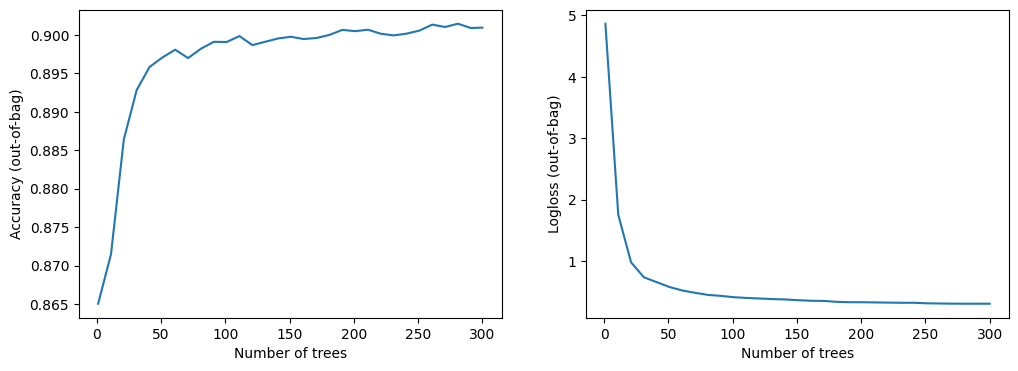

In [14]:
logs = model.make_inspector().training_logs()

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot([log.num_trees for log in logs], [log.evaluation.accuracy for log in logs])
plt.xlabel("Number of trees")
plt.ylabel("Accuracy (out-of-bag)")
plt.subplot(1, 2, 2)
plt.plot([log.num_trees for log in logs], [log.evaluation.loss for log in logs])
plt.xlabel("Number of trees")
plt.ylabel("Logloss (out-of-bag)")
plt.show()

Calculate the score of our hold-out validation dataset

In [15]:
predictions = model.predict(val_ds)
y_true      = validation_data["label"]

from sklearn.metrics import roc_auc_score
ROC_AUC = roc_auc_score(y_true, predictions)
print("The ROC AUC score is %.5f" % ROC_AUC )

 1/12 [=>............................] - ETA: 1s

 4/12 [=========>....................] - ETA: 0s

 7/12 [================>.............] - ETA: 0s

10/12 [========================>.....] - ETA: 0s

12/12 [==============================] - 0s 22ms/step


The ROC AUC score is 0.98076


In [16]:
# Compute binary classification metrics with sklearn
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
    log_loss,
    brier_score_loss,
)

# Get predictions (probabilities or class labels)
preds = model.predict(test_ds)
# If model outputs probabilities, convert to labels by threshold 0.5
if preds.ndim == 2:
    # For TFDF classification, preds may be class probabilities with shape (N, 2)
    if preds.shape[1] == 2:
        pos_probs = preds[:, 1]
    else:
        # If single-probability column (positive class)
        pos_probs = preds[:, -1]
    y_pred = (pos_probs >= 0.5).astype(int)
else:
    # Already class labels
    y_pred = preds.astype(int)
    pos_probs = None

# Ground truth labels (must be 0/1 integers)
y_true = test_data["label"].astype(int).to_numpy()

# Core metrics
metrics = {}
metrics["accuracy"] = accuracy_score(y_true, y_pred)
metrics["precision"] = precision_score(y_true, y_pred, zero_division=0)
metrics["recall"] = recall_score(y_true, y_pred, zero_division=0)
metrics["f1"] = f1_score(y_true, y_pred, zero_division=0)
metrics["mcc"] = matthews_corrcoef(y_true, y_pred)

# Probabilistic metrics (only if we have probabilities)
if pos_probs is not None:
    metrics["roc_auc"] = roc_auc_score(y_true, pos_probs)
    metrics["pr_auc"] = average_precision_score(y_true, pos_probs)
    metrics["log_loss"] = log_loss(y_true, pos_probs, labels=[0,1])
    metrics["brier_score"] = brier_score_loss(y_true, pos_probs)

# Confusion matrix and detailed report
cm = confusion_matrix(y_true, y_pred, labels=[0,1])
report = classification_report(y_true, y_pred, digits=4)

print("Sklearn binary metrics:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")
print("\nConfusion matrix:\n", cm)
print("\nClassification report:\n", report)

 1/23 [>.............................] - ETA: 1s

 4/23 [====>.........................] - ETA: 0s

 7/23 [========>.....................] - ETA: 0s

10/23 [============>.................] - ETA: 0s

13/23 [===============>..............] - ETA: 0s

16/23 [===================>..........] - ETA: 0s

19/23 [=======================>......] - ETA: 0s

22/23 [===========================>..] - ETA: 0s

23/23 [==============================] - 1s 23ms/step


Sklearn binary metrics:
accuracy: 0.9711
precision: 0.7887
recall: 0.8221
f1: 0.8050
mcc: 0.7897
roc_auc: 0.9822
pr_auc: 0.8831
log_loss: 0.0895
brier_score: 0.0235

Confusion matrix:
 [[20501   359]
 [  290  1340]]

Classification report:
               precision    recall  f1-score   support

           0     0.9861    0.9828    0.9844     20860
           1     0.7887    0.8221    0.8050      1630

    accuracy                         0.9711     22490
   macro avg     0.8874    0.9024    0.8947     22490
weighted avg     0.9717    0.9711    0.9714     22490

